In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0

In [2]:
model_reg = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
model_reg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_reg = model_reg.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7647 - loss: 0.6478 - val_accuracy: 0.8223 - val_loss: 0.4738
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8263 - loss: 0.4798 - val_accuracy: 0.8471 - val_loss: 0.4356
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8354 - loss: 0.4504 - val_accuracy: 0.8532 - val_loss: 0.4024
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8453 - loss: 0.4263 - val_accuracy: 0.8593 - val_loss: 0.3882
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8499 - loss: 0.4125 - val_accuracy: 0.8569 - val_loss: 0.4000
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8530 - loss: 0.4024 - val_accuracy: 0.8651 - val_loss: 0.3761
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8600 - loss: 0.3903 - val_accuracy: 0.8582 - val_loss: 0.3752
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8590 - loss: 0.3859 - 

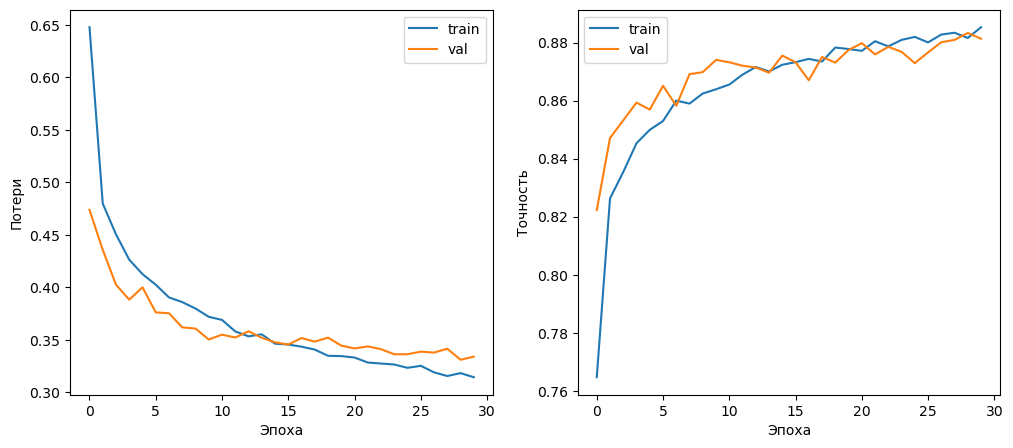

In [3]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_reg.history['loss'], label='train')
plt.plot(history_reg.history['val_loss'], label='val')
plt.xlabel("Эпоха")
plt.ylabel("Потери")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_reg.history['accuracy'], label='train')
plt.plot(history_reg.history['val_accuracy'], label='val')
plt.xlabel("Эпоха")
plt.ylabel("Точность")
plt.legend()

plt.show()

In [4]:
model_no_reg = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_no_reg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_no_reg = model_no_reg.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8270 - loss: 0.4777 - val_accuracy: 0.8590 - val_loss: 0.4019
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8684 - loss: 0.3590 - val_accuracy: 0.8640 - val_loss: 0.3765
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8806 - loss: 0.3235 - val_accuracy: 0.8707 - val_loss: 0.3632
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8879 - loss: 0.3021 - val_accuracy: 0.8591 - val_loss: 0.3821
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8942 - loss: 0.2831 - val_accuracy: 0.8645 - val_loss: 0.3731
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8988 - loss: 0.2682 - val_accuracy: 0.8778 - val_loss: 0.3456
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9030 - loss: 0.2567 - val_accuracy: 0.8642 - val_loss: 0.3676
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9076 - loss: 0.2447 - 

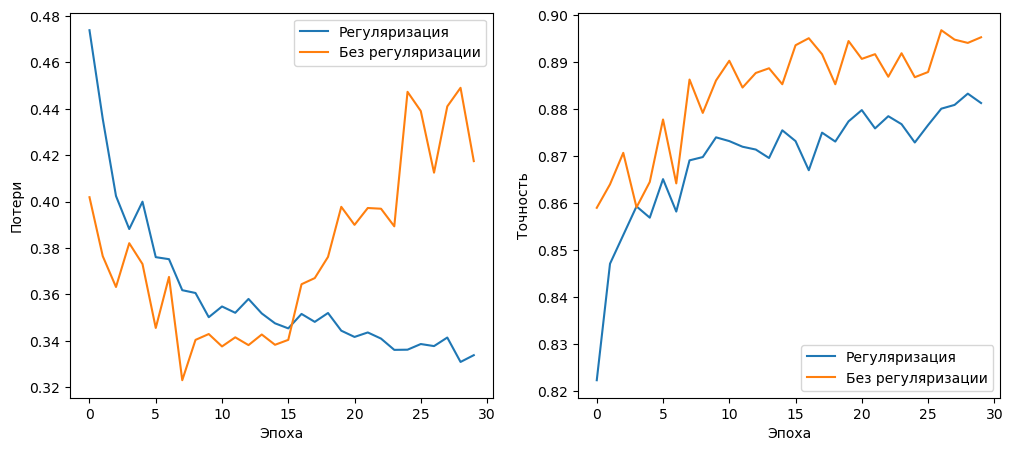

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_reg.history['val_loss'], label='Регуляризация')
plt.plot(history_no_reg.history['val_loss'], label='Без регуляризации')
plt.xlabel("Эпоха")
plt.ylabel("Потери")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_reg.history['val_accuracy'], label='Регуляризация')
plt.plot(history_no_reg.history['val_accuracy'], label='Без регуляризации')
plt.xlabel("Эпоха")
plt.ylabel("Точность")
plt.legend()

plt.show()

In [6]:
model_sigmoid = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='sigmoid'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='sigmoid'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
model_sigmoid.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_sigmoid = model_sigmoid.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7492 - loss: 0.6953 - val_accuracy: 0.8302 - val_loss: 0.4688
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8284 - loss: 0.4740 - val_accuracy: 0.8433 - val_loss: 0.4337
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8459 - loss: 0.4270 - val_accuracy: 0.8541 - val_loss: 0.3987
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8532 - loss: 0.4043 - val_accuracy: 0.8574 - val_loss: 0.3898
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8585 - loss: 0.3872 - val_accuracy: 0.8609 - val_loss: 0.3798
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8639 - loss: 0.3714 - val_accuracy: 0.8690 - val_loss: 0.3600
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8675 - loss: 0.3612 - val_accuracy: 0.8719 - val_loss: 0.3613
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8708 - loss: 0.3520 - 

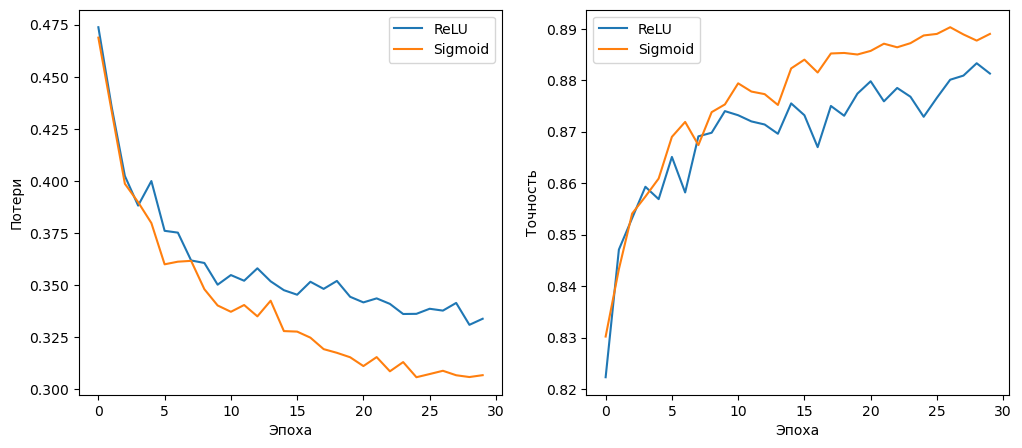

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_reg.history['val_loss'], label='ReLU')
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid')
plt.xlabel("Эпоха")
plt.ylabel("Потери")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_reg.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.xlabel("Эпоха")
plt.ylabel("Точность")
plt.legend()

plt.show()

In [8]:
cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', name='conv_1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', name='conv_2'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn = cnn_model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8333 - loss: 0.4651 - val_accuracy: 0.8731 - val_loss: 0.3503
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8870 - loss: 0.3139 - val_accuracy: 0.8854 - val_loss: 0.3086
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9018 - loss: 0.2673 - val_accuracy: 0.8776 - val_loss: 0.3203
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9121 - loss: 0.2373 - val_accuracy: 0.8916 - val_loss: 0.2876
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9201 - loss: 0.2126 - val_accuracy: 0.9076 - val_loss: 0.2527
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9288 - loss: 0.1906 - val_accuracy: 0.9032 - val_loss: 0.2585
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9355 - loss: 0.1726 - val_accuracy: 0.8996 - val_loss: 0.2815
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9419 - loss: 0.1546 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


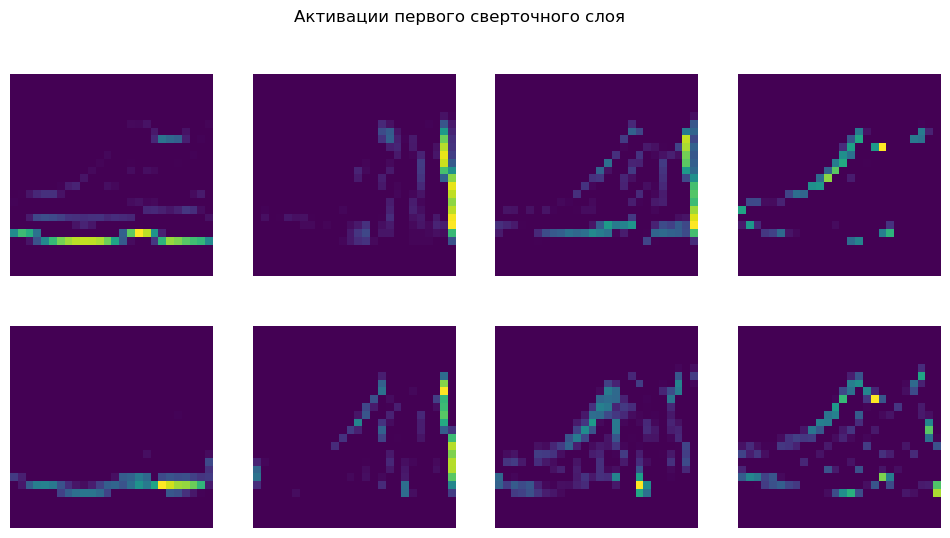

In [9]:
img = test_images[0:1].reshape(1, 28, 28, 1)

conv_layers = [layer for layer in cnn_model.layers if 'conv' in layer.name]
activation_model = tf.keras.Model(
    inputs=cnn_model.layers[0].input, 
    outputs=[layer.output for layer in conv_layers]
)
activations = activation_model.predict(img)

first_layer_activation = activations[0]
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("Активации первого сверточного слоя")
plt.show()

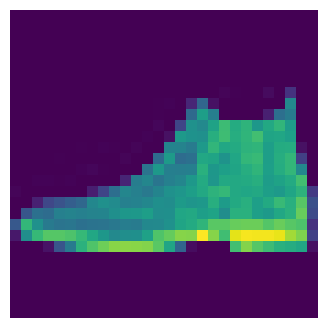

In [10]:
display_img = img.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(display_img)
plt.axis('off')
plt.show()